In [10]:
import numpy as np

In [11]:
from sklearn.base import BaseEstimator

class MyDummyClassifier(BaseEstimator):

  # fit 메서드는 아무것도 학습하지 않음
  def fit(self, X, y=None):
    pass

  # predict 메서드는 단순히 Sex feature가 1이면 0, 그렇지 않으면 1로 예측
  def predict(self, X):

    pred = np.zeros((X.shape[0], 1))

    for i in range(X.shape[0]):
      if X['Sex'].iloc[i] == 1:
        pred[i] = 0
      else:
        pred[i] = 1

    return pred

In [12]:
from sklearn.preprocessing import LabelEncoder

# Null 처리 함수
def fillna(df):

  df['Age'].fillna(df['Age'].mean(), inplace=True)
  df['Cabin'].fillna('N', inplace=True)
  df['Embarked'].fillna('N', inplace=True)
  df['Fare'].fillna(0, inplace=True)

  return df

# 머신러닝 알고리즘에 불필요한 피처 제거
def drop_features(df):

  df.drop(['PassengerId', 'Name', 'Ticket'], axis = 1, inplace=True)

  return df


# 레이블 인코딩 진행
def format_features(df):

  df['Cabin'] = df['Cabin'].str[:1]
  features = ['Cabin', 'Sex', 'Embarked']

  for feature in features:
    le = LabelEncoder()
    le = le.fit(df[feature])
    df[feature] = le.transform(df[feature])

  return df

# 앞에서 설정한 데이터 전처리 함수 호출
def transform_features(df):

  df = fillna(df)
  df = drop_features(df)
  df = format_features(df)

  return df

In [13]:
# 생존자 예측
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 원본데이터를 재로딩, 데이터 가공, 학습데이터/ 테스트 데이터 분할
titanic_df = pd.read_csv('./titanic_train.csv')
y_titanic_df = titanic_df['Survived']
X_titanic_df = titanic_df.drop('Survived', axis = 1)
X_titanic_df = transform_features(X_titanic_df)
X_train, X_test, y_train, y_test = train_test_split(X_titanic_df, y_titanic_df, test_size=0.2, random_state = 0)

/var/folders/03/tjygvdy92d1dxrlj14826_700000gn/T/ipykernel_43357/106575283.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
/var/folders/03/tjygvdy92d1dxrlj14826_700000gn/T/ipykernel_43357/106575283.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always

In [14]:
# 위에서 생성한 Dummy Classifier를 이용해 학습/예측/평가 수행.
import numpy as np

myclf = MyDummyClassifier()
myclf.fit(X_train, y_train)

my_predictions = myclf.predict(X_test)
print('Dummy Classifier 의 정확도는:{0:.4f}'.format(accuracy_score(y_test, my_predictions)))

Dummy Classifier 의 정확도는:0.7877


In [15]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

class MyFakeCLassifier(BaseEstimator):

  def fit(self, X, y):
    pass

  # 입력값으로 들어오는 X 데이터세트 크기만큼 모두 0값으로 만들어서 반환
  def predict(self, X):
    return np.zeros((len(X), 1), dtype=bool)

# 사이킷런의 내장 데이터 세트인 load_digits()을 이용해 MNIST 데이터 로딩
digits = load_digits()

# digits 번호가 7이면 True 이고 이를 astype(int)로 1로 변환, 7번 아니면 False 아고 0으로 변환
y = (digits.target == 7).astype(int)
X_train, X_test, y_train, y_test = train_test_split(digits.data, y, random_state=11)

In [16]:
# 불균형한 레이블 데이터 분포도 확인
print('레이블 테스트 크기:', y_test.shape)
print('테스트 세트 레이블 0과 1의 분포도')
print(pd.Series(y_test).value_counts())

# Dummy Classifier 로 학습/예측/정확도 평가
fake_clf = MyFakeCLassifier()
fake_clf.fit(X_train, y_train)
fakepred = fake_clf.predict(X_test)

print('모든 예측을 0으로 하여도 정확도는:{:.3f}'.format(accuracy_score(y_test,fakepred)))

레이블 테스트 크기: (450,)
테스트 세트 레이블 0과 1의 분포도
0    405
1     45
Name: count, dtype: int64
모든 예측을 0으로 하여도 정확도는:0.900


In [17]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, fakepred)

array([[405,   0],
       [ 45,   0]])

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

def get_clf_eval(y_test,pred):

  confusion = confusion_matrix(y_test, pred)
  accuracy = accuracy_score(y_test, pred)
  precision = precision_score(y_test, pred)
  recall = recall_score(y_test, pred)

  print('오차행렬')
  print(confusion)
  print('정확도: {0:.4f}, 정밀도:{1:.4f}, 재현율{1:.4f}'.format(accuracy, precision, recall))

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# 원본 데이터를 재로딩, 데이터 가공, 학습 데이터, 테스트 데이터 분할.
titanic_df = pd.read_csv('./titanic_train.csv')
y_titanic_df = titanic_df['Survived']
X_titanic_df = titanic_df.drop(['Survived'], axis = 1)
X_titanic_df = transform_features(X_titanic_df)

X_train, X_test, y_train, y_test = train_test_split(X_titanic_df, y_titanic_df, test_size = 0.2, random_state = 0)

lr_clf = LogisticRegression(solver = 'liblinear')
lr_clf.fit(X_train, y_train)

/var/folders/03/tjygvdy92d1dxrlj14826_700000gn/T/ipykernel_43357/106575283.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
/var/folders/03/tjygvdy92d1dxrlj14826_700000gn/T/ipykernel_43357/106575283.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always

LogisticRegression(solver='liblinear')

In [20]:
pred = lr_clf.predict(X_test)
get_clf_eval(y_test, pred)

오차행렬
[[93 17]
 [20 49]]
정확도: 0.7933, 정밀도:0.7424, 재현율0.7424


In [21]:
# 정밀도 재현율 트레아드 오프
pred_proba = lr_clf.predict_proba(X_test)
pred = lr_clf.predict(X_test)

print('pred_proba()결과 shape:{0}'.format(pred_proba.shape))
print('pred_proba array에서 앞 3개만 샘플로 추출 \n:', pred_proba[:3])

# 예측확률 array와 예측 결과값 array를 병합해 예측확률과 결과값을 한눈에 확인
pred_proba_result = np.concatenate([pred_proba, pred.reshape(-1, 1)], axis =1)

print('두개의 class 중에서 더 큰확률을 클래스 값으로 예측\n', pred_proba_result[:3])

pred_proba()결과 shape:(179, 2)
pred_proba array에서 앞 3개만 샘플로 추출 
: [[0.8515732  0.1484268 ]
 [0.87164644 0.12835356]
 [0.92390378 0.07609622]]
두개의 class 중에서 더 큰확률을 클래스 값으로 예측
 [[0.8515732  0.1484268  0.        ]
 [0.87164644 0.12835356 0.        ]
 [0.92390378 0.07609622 0.        ]]


In [22]:
from sklearn.preprocessing import Binarizer

X = [[1, -1, 2],
     [2, 0,  0],
     [0, 1.1, 1.2]]

# X의 개별 원소들이 threshold값보다 같거나 작으면 0을 크면 1을 반환
binarizer = Binarizer(threshold=1.1)

print(binarizer.fit_transform(X))

[[0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]]


In [23]:
from sklearn.preprocessing import Binarizer

# Binarizer의 threshold 설정값, 분류 결정 임계값임
custom_threshold = 0.5

# predict_proba() 반환값의 두번 째 칼럼, 즉 Positive 클래스 하나만 추출해 Binarizier을 적용
pred_proba_1 = pred_proba[:, 1].reshape(-1, 1)
binarizer = Binarizer(threshold=custom_threshold).fit(pred_proba_1)
custom_predict = binarizer.transform(pred_proba_1)

get_clf_eval(y_test, custom_predict)

오차행렬
[[93 17]
 [20 49]]
정확도: 0.7933, 정밀도:0.7424, 재현율0.7424


In [24]:
# Binarizer의 threshold 설정값을 0.4로 설, 즉 분류 결정 임계값을 0.5 에서 0.4로 낮춤
custom_threshold = 0.4

pred_proba_1 = pred_proba[:, 1].reshape(-1, 1)
binarizer = Binarizer(threshold = custom_threshold).fit(pred_proba_1)
custom_predict = binarizer.transform(pred_proba_1)

get_clf_eval(y_test, custom_predict)

오차행렬
[[87 23]
 [14 55]]
정확도: 0.7933, 정밀도:0.7051, 재현율0.7051


In [25]:
thresholds = [0.4, 0.45, 0.50, 0.55, 0.60]

def get_eval_by_threshold(y_test, pred_proba_c1, thresholds):

  for custom_threshold in thresholds:
    binarizer = Binarizer(threshold=custom_threshold).fit(pred_proba_c1)
    custom_predict = binarizer.transform(pred_proba_c1)

    print('임계값:',custom_threshold)

    get_clf_eval(y_test, custom_predict)

get_eval_by_threshold(y_test, pred_proba[:,1].reshape(-1, 1), thresholds )

임계값: 0.4
오차행렬
[[87 23]
 [14 55]]
정확도: 0.7933, 정밀도:0.7051, 재현율0.7051
임계값: 0.45
오차행렬
[[91 19]
 [18 51]]
정확도: 0.7933, 정밀도:0.7286, 재현율0.7286
임계값: 0.5
오차행렬
[[93 17]
 [20 49]]
정확도: 0.7933, 정밀도:0.7424, 재현율0.7424
임계값: 0.55
오차행렬
[[98 12]
 [23 46]]
정확도: 0.8045, 정밀도:0.7931, 재현율0.7931
임계값: 0.6
오차행렬
[[101   9]
 [ 26  43]]
정확도: 0.8045, 정밀도:0.8269, 재현율0.8269


In [26]:
from sklearn.metrics import precision_recall_curve

# 레이블 값이 1일때의 예측 확률을 추출
pred_proba_class1 = lr_clf.predict_proba(X_test)[:, 1]

# 실제 데이터 세트와 레이블 값이 1일때의 예측확률을 precision_recall_curve 인자로 입력
precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba_class1)

print('반환된 분류 결정 임계값 배열의 Shape:', thresholds.shape)

# 반환된 임계값 배열 로우가 147건임으로 샘플로 10건만 추출하되 ,임계값을 15 step으로 추출
thr_index = np.arange(0, thresholds.shape[0], 15)

print('샘플 추출을 위한 임계값 배열의 index 10개:', thr_index)
print('샘플용 10개의 임계값: ', np.round(thresholds[thr_index], 2))

# 15step으로 단위로 추출된 임계값에 따른 정밀도와 재현율 값
print('샘플 임계값별 정밀도:', np.round(precisions[thr_index], 3))
print('샘플 임계값별 재현율:', np.round(recalls[thr_index], 3))

반환된 분류 결정 임계값 배열의 Shape: (166,)
샘플 추출을 위한 임계값 배열의 index 10개: [  0  15  30  45  60  75  90 105 120 135 150 165]
샘플용 10개의 임계값:  [0.08 0.12 0.13 0.16 0.19 0.26 0.42 0.54 0.65 0.76 0.87 0.96]
샘플 임계값별 정밀도: [0.399 0.418 0.478 0.52  0.585 0.659 0.711 0.754 0.87  1.    1.    1.   ]
샘플 임계값별 재현율: [1.    0.957 0.957 0.928 0.899 0.87  0.783 0.667 0.58  0.449 0.232 0.014]


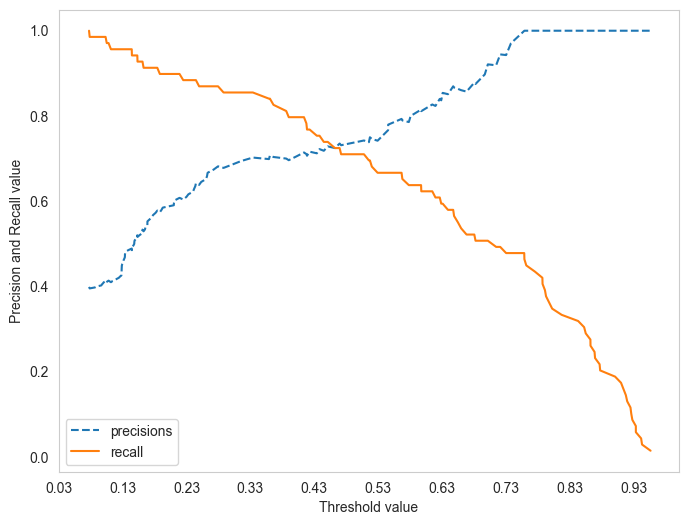

In [27]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

%matplotlib inline

def precision_recall_curve_plot(y_test, pred_proba_c1):

  # threshold ndarray와 이 threshold에 따른 정밀도, 재현율 ndarray 추출
  plt.figure(figsize=(8, 6))
  threshold_boundary = thresholds.shape[0]

  plt.plot(thresholds, precisions[0: threshold_boundary], linestyle='--', label = 'precisions')
  plt.plot(thresholds, recalls[0: threshold_boundary], label = 'recall')

  start, end = plt.xlim()
  plt.xticks(np.round(np.arange(start, end, 0.1), 2))
  plt.xlabel('Threshold value');plt.ylabel('Precision and Recall value')
  plt.legend();plt.grid()
  plt.show()

precision_recall_curve_plot(y_test, lr_clf.predict_proba(X_test)[:, 1])

In [28]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, pred)

print('F1 스코어:{0:.4f}'.format(f1))

F1 스코어:0.7259


In [29]:
def get_clf_eval(y_test, pred):

  confusion = confusion_matrix(y_test, pred)
  accuracy = accuracy_score(y_test, pred)
  precision = precision_score(y_test, pred)
  recall = recall_score(y_test, pred)

  #F1 스코어 추가
  f1 = f1_score(y_test,pred)

  print('오차행렬')
  print(confusion)

  #f1 score print 추가

  print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}, F1:{3:.4f}'.format(accuracy, precision, recall, f1))

In [30]:
thresholds = [0.4, 0.45, 0.50, 0.55, 0.60]
pred_proba = lr_clf.predict_proba(X_test)
get_eval_by_threshold(y_test, pred_proba[:, 1].reshape(-1, 1), thresholds)

임계값: 0.4
오차행렬
[[87 23]
 [14 55]]
정확도: 0.7933, 정밀도: 0.7051, 재현율: 0.7971, F1:0.7483
임계값: 0.45
오차행렬
[[91 19]
 [18 51]]
정확도: 0.7933, 정밀도: 0.7286, 재현율: 0.7391, F1:0.7338
임계값: 0.5
오차행렬
[[93 17]
 [20 49]]
정확도: 0.7933, 정밀도: 0.7424, 재현율: 0.7101, F1:0.7259
임계값: 0.55
오차행렬
[[98 12]
 [23 46]]
정확도: 0.8045, 정밀도: 0.7931, 재현율: 0.6667, F1:0.7244
임계값: 0.6
오차행렬
[[101   9]
 [ 26  43]]
정확도: 0.8045, 정밀도: 0.8269, 재현율: 0.6232, F1:0.7107


In [31]:
from sklearn.metrics import roc_curve

# 레이블 값이 1일때의 예측 확률을 추출
pred_proba_class1 = lr_clf.predict_proba(X_test)[:, 1]

fprs, tprs, thresholds = roc_curve(y_test, pred_proba_class1)

# 반환된 임계값 배열에서 샘플로 데이터를 추출하되, 임계값을 5step으로 추출
# threshold[0]은 max(예측확률) + 1로 임의 설정됨. 이를 제외하기 위해 np.arange는 1부터 시작
thr_index = np.arange(1, thresholds.shape[0], 5)

print('샘플 추출을 위한 임계값 배열의 index:', thr_index)
print('샘플 index로 추출한 임계값', np.round(thresholds[thr_index], 2))

# 5step 단위로 추출된 임계값에 따른 FPR, TPR 값
print('샘플 임계값 별 FPR:', np.round(fprs[thr_index], 3))
print('샘플 임계값 별 TPR:', np.round(tprs[thr_index], 3))

샘플 추출을 위한 임계값 배열의 index: [ 1  6 11 16 21 26 31 36 41 46 51 56 61 66]
샘플 index로 추출한 임계값 [0.96 0.7  0.64 0.61 0.53 0.47 0.43 0.36 0.25 0.18 0.16 0.13 0.11 0.04]
샘플 임계값 별 FPR: [0.    0.027 0.064 0.082 0.145 0.164 0.191 0.218 0.309 0.418 0.527 0.682
 0.864 1.   ]
샘플 임계값 별 TPR: [0.014 0.507 0.58  0.623 0.667 0.725 0.754 0.841 0.87  0.913 0.928 0.957
 0.971 1.   ]


In [32]:
def roc_curve_plot(y_test, pred_proba_c1):

  #임계값에 따른 FPR, TPR 값을 반환받음
  fprs, tprs, thresholds = roc_curve(y_test, pred_proba_c1)

  #ROC곡선을 그래프 곡선으로 그림
  plt.plot(fprs, tprs, label='ROC')

  #가운데 대각선 직선을 그림
  plt.plot([0, 1], [0, 1], 'k--', label='Random')

  #FPR X축의 Scale을 0.1 단위로 변경 X축, Y축 명 설정 등
  start, end = plt.xlim()
  plt.xticks(np.round(np.arange(start, end, 0.1), 2))
  plt.xlim(0, 1); plt.ylim(0, 1)
  plt.xlabel('FPR(1-Specificity)'); plt.ylabel('TPR(Recall)')
  plt.legend()
  plt.show()

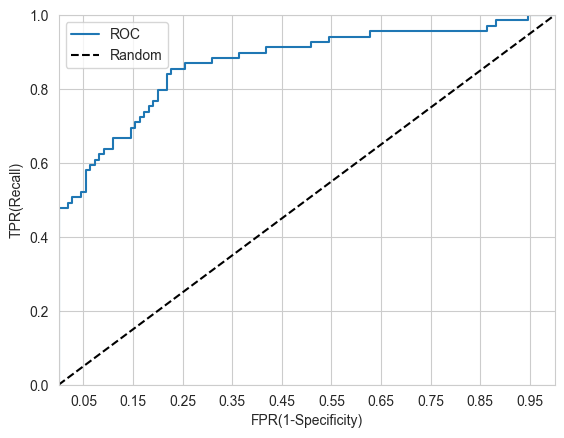

In [33]:
roc_curve_plot(y_test, pred_proba[:, 1])

In [34]:
from sklearn.metrics import roc_auc_score

pred_proba = lr_clf.predict_proba(X_test)[:, 1]
roc_score = roc_auc_score(y_test, pred_proba)

print('ROC AUC 값: {0:.4f}'.format(roc_score))

ROC AUC 값: 0.8697


In [35]:
def get_clf_eval(y_test, pred=None, pred_proba = None):

  confusion = confusion_matrix(y_test, pred)
  accuracy = accuracy_score(y_test, pred)
  precision = precision_score(y_test, pred)
  recall = recall_score(y_test, pred)
  f1 = f1_score(y_test, pred)

  # ROC_AUC 추가
  roc_auc = roc_auc_score(y_test, pred_proba)

  print('오차행렬')
  print(confusion)

  # ROC_AUC print 추가
  print('정확도: {0:.4f}, 정밀도: {1: 4f}, 재현율: {2: 4f}, F1:{3: 4f}, AUC:{4: 4f}'.format(accuracy, precision, recall, f1, roc_auc))

In [36]:
get_clf_eval(y_test, pred, pred_proba)

오차행렬
[[93 17]
 [20 49]]
정확도: 0.7933, 정밀도:  0.742424, 재현율:  0.710145, F1: 0.725926, AUC: 0.869697


In [37]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings('ignore')

# DecisionTreeClassifier  생성
dt_clf = DecisionTreeClassifier(random_state = 156)

# 붓꽃데이터를 로딩하고 학습데이터와 테스트 데이터 세트를 분리
iris_data = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris_data.data, iris_data.target, test_size = 0.2, random_state = 11)
dt_clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=156)

In [55]:
from sklearn.tree import export_graphviz

# export_graphviz의 호출 결과로 outfile로 지정 된 treedot 파일을 생성함
export_graphviz(dt_clf, out_file = "tree.dot", class_names=iris_data.target_names, feature_names = iris_data.feature_names, impurity= True, filled = True)

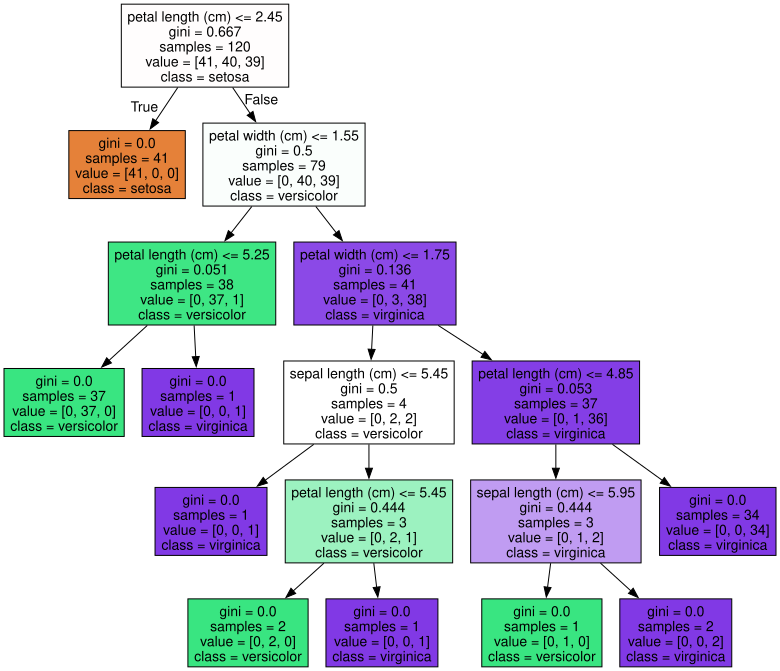

In [56]:
import graphviz

with open("tree.dot") as f:
  dot_graph = f.read()
graphviz.Source(dot_graph)

Feature importances:
[0.025 0.    0.555 0.42 ]
sepal length (cm) : 0.025
sepal width (cm) : 0.000
petal length (cm) : 0.555
petal width (cm) : 0.420


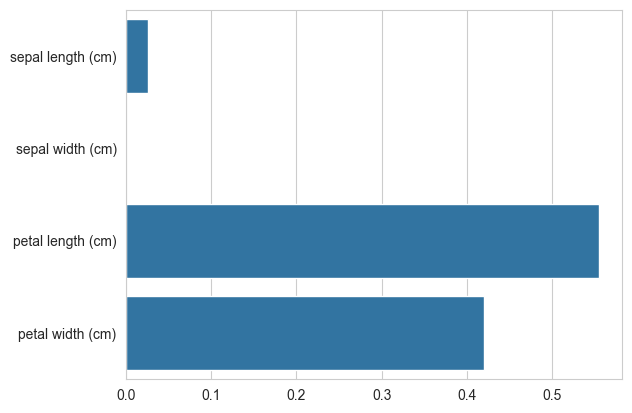

In [57]:
# feature가 얼마나 중요한지 뽑아주는 지표 feature_importance
import seaborn as sns
import numpy as np

%matplotlib inline

# feature importance 추출
print("Feature importances:\n{0}".format( np.round(dt_clf.feature_importances_, 3)) )

# feature 별 importance 매핑
for name, value in zip(iris_data.feature_names, dt_clf.feature_importances_):
  print('{0} : {1:.3f}'.format(name, value))
sns.barplot(x=dt_clf.feature_importances_, y = iris_data.feature_names)

# feature importance를 컬럼별로 시각화하기
plt.show()

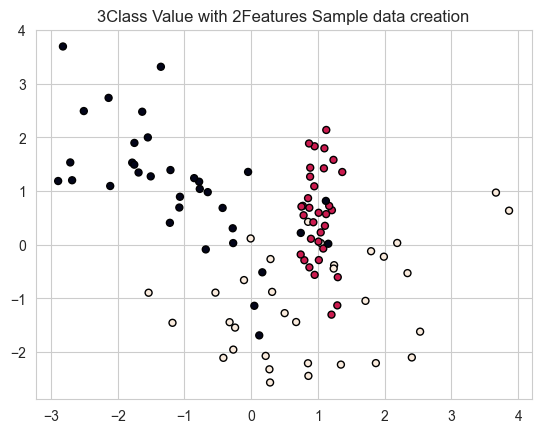

In [58]:
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt

%matplotlib inline

plt.title('3Class Value with 2Features Sample data creation')
X_features, y_labels = make_classification(n_features=2, n_redundant=0, n_informative=2,
                                           n_classes=3, n_clusters_per_class=1, random_state=0)

# 그래프 형태로 2개의 피처로 2차원 좌표 시각화 각 클라스 삾은 색깔로 표시됨
plt.scatter(X_features[:,0], X_features[:, 1], marker='o', c = y_labels, s=25, edgecolor='k')
plt.show()

In [59]:
def visualize_boundary(model, X, y):
  fig,ax = plt.subplots()

  # 학습 데이타 scatter plot으로 나타내기
  ax.scatter(X[:, 0], X[:, 1], c=y, s=25, cmap='rainbow', edgecolor='k',
             clim=(y.min(), y.max()), zorder=3)

  ax.axis('tight')
  ax.axis('off')
  xlim_start , xlim_end = ax.get_xlim()
  ylim_start , ylim_end = ax.get_ylim()

  # 호출 파라미터로 들어온 training 데이타로 model 학습
  model.fit(X, y)

  # meshgrid 형태인 모든 좌표값으로 예측 수행.
  xx, yy = np.meshgrid(np.linspace(xlim_start,xlim_end, num=200),np.linspace(ylim_start,ylim_end, num=200))
  Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

  # contourf() 를 이용하여 class boundary 를 visualization 수행
  n_classes = len(np.unique(y))
  contours = ax.contourf(xx, yy, Z, alpha=0.3,
                         levels=np.arange(n_classes + 1) - 0.5,
                         cmap='rainbow', clim=(y.min(), y.max()),
                         zorder=1)

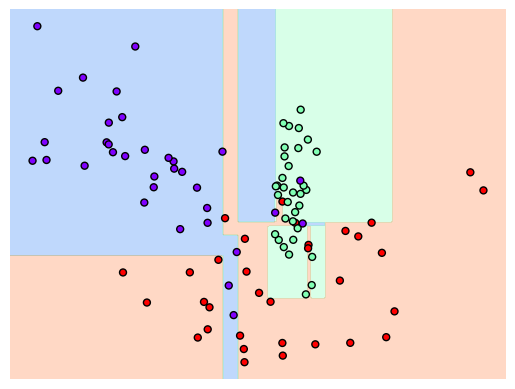

In [60]:
from sklearn.tree import DecisionTreeClassifier

# 특정한 트리 생성 제약 없는 결정트리의 학습과 결정 경계 시각화
dt_clf = DecisionTreeClassifier(random_state = 156).fit(X_features, y_labels)
visualize_boundary(dt_clf, X_features, y_labels)
plt.show()

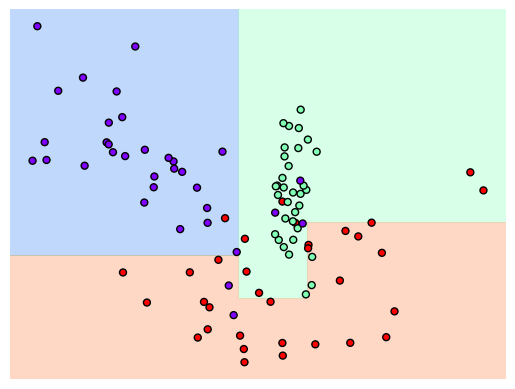

In [61]:
dt_clf =DecisionTreeClassifier(min_samples_leaf = 6, random_state = 156).fit(X_features, y_labels)
visualize_boundary(dt_clf, X_features, y_labels)
plt.show()

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

# feature.txt 파일에는 피처 이름 인덱스와 피처명이 공백으로 분리되어 있음 이를 DataFrame으로 로드
feature_name_df = pd.read_csv('./UCI HAR Dataset/human_activity/features.txt',sep='\s+',
                              header =None, names = ['column_index', 'column_name'])

In [66]:
# 피처 index를 제거 하고 피처명만 리스트 객체로 생성한뒤 샘플로 10개만 추출
feature_name = feature_name_df.iloc[:, 1].values.tolist()

print('전체 피처명에서 10개만 추출:', feature_name[:10])

전체 피처명에서 10개만 추출: ['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z', 'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z', 'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z', 'tBodyAcc-max()-X']


In [67]:
feature_dup_df = feature_name_df.groupby('column_name').count()

print(feature_dup_df[feature_dup_df['column_index'] > 1].count())
feature_dup_df[feature_dup_df['column_index'] > 1].head()

column_index    42
dtype: int64


,column_index
column_name,
"fBodyAcc-bandsEnergy()-1,16",3
"fBodyAcc-bandsEnergy()-1,24",3
"fBodyAcc-bandsEnergy()-1,8",3
"fBodyAcc-bandsEnergy()-17,24",3
"fBodyAcc-bandsEnergy()-17,32",3


In [68]:
def get_new_feature_name_df(old_feature_name_df):

  feature_dup_df = pd.DataFrame(data=old_feature_name_df.groupby('column_name').cumcount(),
                                columns=['dup_cnt'])

  feature_dup_df = feature_dup_df.reset_index()
  new_feature_name_df = pd.merge(old_feature_name_df.reset_index(), feature_dup_df, how='outer')
  new_feature_name_df['column_name'] = (new_feature_name_df[['column_name', 'dup_cnt']]
                                        .apply(lambda x : x[0]+'_'+str(x[1]) if x[1] >0 else x[0] ,  axis=1))

  new_feature_name_df = new_feature_name_df.drop(['index'], axis=1)

  return new_feature_name_df

In [71]:
import pandas as pd
def get_human_dataset():

  # 각 데이터 파일은 공백으로 분리되어 있으므로 read_csv에서 공백 문자를 sep으로 할당
  feature_name_df = pd.read_csv('./UCI HAR Dataset/human_activity/features.txt',sep='\s+',
                                header =None, names = ['column_index', 'column_name'])

  # 중복된 피처명을 수정하는 get_new_feature_name_df()를 이용, 신규 피러명 DataFrame 생성
  new_feature_name_df = get_new_feature_name_df(feature_name_df)

  # DataFrame에 피처명을 칼럼으로 부여하기 위해 리스트 객체로 다시 변환
  feature_name = new_feature_name_df.iloc[:,1].values.tolist()

  # 학습 피처 데이터 세트와 테스트 데이터 피처를 DataFrame으로 로딩, 칼럼명은 featurename 적용
  X_train = pd.read_csv('./UCI HAR Dataset/human_activity/train/X_train.txt', sep = '\s+', names=feature_name )
  X_test = pd.read_csv('./UCI HAR Dataset/human_activity/test/X_test.txt', sep = '\s+', names=feature_name )

  #학습 레이블과 테스트 레이블 데이터를 DataFrame으로 로딩하고 칼럼명은 action으로 부여
  y_train = pd.read_csv('./UCI HAR Dataset/human_activity/train/y_train.txt', sep = '\s+',header=None, names=['action'] )
  y_test = pd.read_csv('./UCI HAR Dataset/human_activity/test/y_test.txt', sep = '\s+',header=None, names=['action'] )

  return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = get_human_dataset()

In [72]:
print('##학습 피처 데이터셋 info')
print(X_train.info())

##학습 피처 데이터셋 info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 561 entries, tBodyAcc-mean()-X to angle(Z,gravityMean)
dtypes: float64(561)
memory usage: 31.5 MB
None


In [73]:
print(y_train['action'].value_counts())

action
6    1407
5    1374
4    1286
1    1226
2    1073
3     986
Name: count, dtype: int64


In [74]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 예제 반복 시마다 동일한 예측 결과 도출을 위해 random_state 설정
dt_clf = DecisionTreeClassifier(random_state=156)
dt_clf.fit(X_train, y_train)
pred = dt_clf.predict(X_test)
accuracy = accuracy_score(y_test, pred)

print('결정 트리 예측 정확도: {0:.4f}'.format(accuracy))

# DecisionTreeClassifier의 하이퍼 파라미터 추출
print('DecisionTreeClassifier 기본 하이퍼 파라미터:\n', dt_clf.get_params())

결정 트리 예측 정확도: 0.8548
DecisionTreeClassifier 기본 하이퍼 파라미터:
 {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'random_state': 156, 'splitter': 'best'}


In [75]:
from sklearn.model_selection import GridSearchCV

params = {
  'max_depth' : [6, 8, 10, 12, 16, 20, 24],
  'min_samples_split': [16]
}

grid_cv = GridSearchCV(dt_clf, param_grid = params, scoring = 'accuracy', cv=5, verbose =1)
grid_cv.fit(X_train, y_train)

print('GridSearchCV의 최고 정확도 수치:{0:.4f}'.format(grid_cv.best_score_))

Fitting 5 folds for each of 7 candidates, totalling 35 fits
GridSearchCV의 최고 정확도 수치:0.8549


In [76]:
print('GridSearchCV 최적 하이퍼 파라미터:', grid_cv.best_params_)

GridSearchCV 최적 하이퍼 파라미터: {'max_depth': 8, 'min_samples_split': 16}


In [77]:
# GridSearchCV 객체의 cv_results_ 속성을 Dataframe으로 생성
cv_results_df = pd.DataFrame(grid_cv.cv_results_)

# max_depth 파라미터 값과 그때의 테스트 세트, 학습 데이터 세트의 정확도 수치 추출
cv_results_df[['param_max_depth', 'mean_test_score']]

,param_max_depth,mean_test_score
0,6,0.847662
1,8,0.854879
2,10,0.852705
3,12,0.845768
4,16,0.847127
5,20,0.848624
6,24,0.848624


In [78]:
max_depths = [6, 8, 10, 12, 16, 20, 24]

# max_depth 값을 변화시키면서 그때마다 학습과 테스트 세트에서의 예측 성능 측정
for depth in max_depths:

  dt_clf = DecisionTreeClassifier(max_depth=depth, min_samples_split = 16, random_state =156)
  dt_clf.fit(X_train, y_train)
  pred = dt_clf.predict(X_test)
  accuracy = accuracy_score(y_test, pred)

  print('max_depth = {0} 정확도:{1:.4f}'.format(depth, accuracy))

max_depth = 6 정확도:0.8551
max_depth = 8 정확도:0.8717
max_depth = 10 정확도:0.8599
max_depth = 12 정확도:0.8571
max_depth = 16 정확도:0.8599
max_depth = 20 정확도:0.8565
max_depth = 24 정확도:0.8565


In [80]:
params={
  'max_depth': [8, 12, 16, 20],
  'min_samples_split': [16, 24]
}

grid_cv = GridSearchCV(dt_clf, param_grid=params, scoring = 'accuracy', cv=5, verbose=1 )
grid_cv.fit(X_train, y_train)

print('GridSearchCV 최고 평균 정확도 수치:{0:.4f}'.format(grid_cv.best_score_))
print('GridSearchCV 최적 하이퍼 파라미터:',grid_cv.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
GridSearchCV 최고 평균 정확도 수치:0.8549
GridSearchCV 최적 하이퍼 파라미터: {'max_depth': 8, 'min_samples_split': 16}


In [81]:
best_df_clf = grid_cv.best_estimator_
pred1 = best_df_clf.predict(X_test)
accuracy = accuracy_score(y_test, pred1)

print('결정 트리 예측 정확도:{0:.4f}'.format(accuracy))

결정 트리 예측 정확도:0.8717


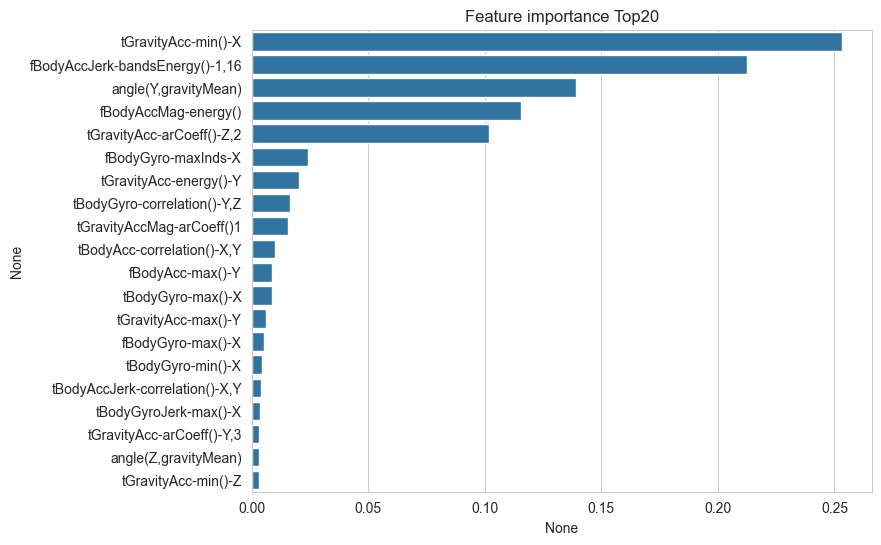

In [82]:
import seaborn as sns

ftr_importances_values = best_df_clf.feature_importances_

# Top 중요도로 정렬을 쉽게하고 시본의 막대그래프로 쉽게 표현하기 위해 Series 변환
# 중요도 순으로 Series 정렬
ftr_importances = pd.Series(ftr_importances_values, index =X_train.columns )
ftr_top20 = ftr_importances.sort_values(ascending=False)[:20]
plt.figure(figsize=(8,6))
plt.title('Feature importance Top20')
sns.barplot(x=ftr_top20, y= ftr_top20.index)
plt.show()

In [83]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')

# 보스턴 데이터세트 업로드
california_housing = fetch_california_housing()
cali_DF = pd.DataFrame(california_housing.data, columns = california_housing.feature_names)
cali_DF['PRICE'] = california_housing.target
y_target = cali_DF['PRICE']
X_data = cali_DF.drop(['PRICE'], axis =1, inplace =False)
rf = RandomForestRegressor(random_state=0, n_estimators=1000)
neg_mse_scores = cross_val_score(rf, X_data, y_target, scoring='neg_mean_squared_error', cv=5)
rmse_scores = np.sqrt(-1*neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

print(' 5교차 검증의 개별 Negative MSE scores: ', np.round(neg_mse_scores, 2))
print(' 5교차 검증의 개별 RMSE scores: ', np.round(rmse_scores, 2))
print(' 5교차 검증의 평균 RMSE: {0:.3f}'.format(avg_rmse))

 5교차 검증의 개별 Negative MSE scores:  [-0.52 -0.34 -0.37 -0.44 -0.46]
 5교차 검증의 개별 RMSE scores:  [0.72 0.59 0.61 0.66 0.68]
 5교차 검증의 평균 RMSE: 0.651


In [85]:
def get_model_cv_prediction(model, X_data, y_target):

  neg_rmse_scores = cross_val_score(model, X_data, y_target, scoring='neg_mean_squared_error', cv = 5)
  rmse_scores = np.sqrt(-1 * neg_mse_scores)
  avg_rmse = np.mean(rmse_scores)

  print('##### ', model.__class__.__name__, '####')
  print(' 5교차 검증의 평균 RMSE : {0:.3f}'.format(avg_rmse))

In [98]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

dt_reg = DecisionTreeRegressor(random_state=0, max_depth=4)
rf_reg = RandomForestRegressor(random_state=0, n_estimators=1000)
gb_reg = GradientBoostingRegressor(random_state=0, n_estimators=1000)

xgb_reg = XGBRegressor(n_estimators=1000)
lgb_reg = LGBMRegressor(n_estimators=1000)

# 트리 기반의 회귀 모델을 반복시키면서 평가 수행
models = [dt_reg, rf_reg, gb_reg, xgb_reg, lgb_reg]

for model in models:
  get_model_cv_prediction(model, X_data, y_target)

ImportError: cannot import name 'XGBRegressor' from 'xgboost' (unknown location)

In [99]:
import seaborn as sns

%matplotlib inline

rf_reg = RandomForestRegressor(n_estimators=1000)

# 앞 예제에서 만들어진 X_data, y_target 데이터 세트를 적용해 학습합니다.
rf_reg.fit(X_data, y_target)

feature_series = pd.Series(data=rf_reg.feature_importances_, index=X_data.columns )
feature_series = feature_series.sort_values(ascending=False)

sns.barplot(x= feature_series, y= feature_series.index)

<Axes: xlabel='None', ylabel='None'>

In [100]:
# 피처별 중요도가 제일 높은 RM을 선정

bostonDF_sample = cali_DF[['RM', 'PRICE']]
bostonDF_sample = bostonDF_sample.sample(n_100, random_state=0)

print(bostonDF_sample.shape)

plt.figure()
plt.scatter(bostonDF_sample.RM, bostonDF_sample.PRICE, c = 'darkorange')
plt.show()

KeyError: "['RM'] not in index"

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression

# 선형 회귀와 결정 트리 기반의 Regressor 생성 , DecisionTreeRegressor 의 maxdepth는 각각 2, 7
lr_reg = LinearRegression()
rf_reg2 = DecisionTreeRegressor(max_depth=2)
rf_reg7 = DecisionTreeRegressor(max_depth=7)

# 실제 예측을 적용할때 테스트용 데이터 세트를 4.5 ~ 8.5까지의 100개 데이터 세트로 생성
X_test = np.arange(4.5, 8.5, 0.04).reshape(-1, 1)

# 보스턴 주택 가격 데이터 에서 시각화를 위해 피처는 RM만 그리고 결정 데이터인 Price 추출
X_feature = bostonDF_sample['RM'].values.reshape(-1, 1)
y_target = bostonDF_sample['PRICE'].values.reshape(-1, 1)

# 학습과 예측 수행
lr_reg.fit(X_feature, y_target)
rf_reg2.fit(X_feature, y_target)
rf_reg7.fit(X_feature, y_target)

pred_lr = lr_reg.predict(X_test)
pred_rf2 =rf_reg2.predict(X_test)
pred_rf7 = rf_reg7.predict(X_test)

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(figsize=(14, 4), ncols=3)

# X축 값을 4.5 ~ 8.5로 변환해서 입력했을때 선형회귀와 결정트리 예측선 시각화
#선형 회귀로 학습된 모델 회귀 예측선
ax1.set_title('Linear Regression')
ax1.scatter(bostonDF_sample.RM, bostonDF_sample.PRICE, c="darkorange")
ax1.plot(X_test, pred_lr, label='linear', linewidth=2)

# DecisionTreeRegressor의 maxdepth를 2로 했을 때 회귀 예측 선
ax2.set_title('Decision Tree Regression: \n max_depth=2')
ax2.scatter(bostonDF_sample.RM, bostonDF_sample.PRICE, c="darkorange")
ax2.plot(X_test, pred_rf2, label='max_depth:3', linewidth=2)

# DecisionTreeRegressor의 maxdepth를 7로 했을 때 회귀 예측 선
ax2.set_title('Decision Tree Regression: \n max_depth=7')
ax2.scatter(bostonDF_sample.RM, bostonDF_sample.PRICE, c="darkorange")
ax2.plot(X_test, pred_rf7, label='max_depth:7', linewidth=2)

plt.show()